# Enhancing 311 Service Requests with ArcGIS AI Utility Services

This sample demonstrates how to use **ArcGIS AI Utility Services** with the ArcGIS API for Python to enhance real-world 311 service request data.

You will learn how to:
- Analyze image attachments using AI
- Summarize unstructured request descriptions
- Translate results into multiple languages
- Visualize enriched data using renderers and popups

By the end, raw service requests are transformed into structured, actionable insights.

## Setup

We begin by importing required modules and connecting to a GIS.

This workflow uses:
- `arcgis.ai` for AI-powered analysis
- `arcgis.map` for visualization
- Renderer and popup dataclasses for modern map configuration

In [ ]:
from arcgis.gis import GIS
from arcgis.map import Map
from arcgis.map.popups import PopupInfo, FieldInfo
from arcgis.map.renderers import ClassBreaksRenderer, ClassBreakInfo, SimpleRenderer
from arcgis.map.symbols import SimpleMarkerSymbolEsriSMS as SimpleMarkerSymbol
from arcgis.map.symbols import SimpleFillSymbolEsriSFS
import pandas as pd
import json
import html

gis = GIS(profile="your_online_profile")

## Helper Methods

Utility functions are used to safely parse and handle responses returned from AI services.

Since AI responses are structured as JSON strings, these helpers ensure consistent parsing before storing results back into the feature layer.

In [ ]:
def _maybe_json(val):
    """Assess whether the value is json"""
    if not isinstance(val, str):
        return val
    s = val.strip()
    if (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]")):
        try:
            return json.loads(s)
        except Exception:
            return val
    return val

def _to_bool_int(val):
    """Translate the boolean value to int of either 0 or 1"""
    if isinstance(val, bool):
        return 1 if val else 0
    if isinstance(val, str):
        return 1 if val.lower() == "true" else 0
    return None

def _chunk(iterable, size=200):
    """Chunk the data for updates"""
    for i in range(0, len(iterable), size):
        yield iterable[i:i+size]

def _safe_field_text(v):
    """Ensure the text is safely formatted"""
    if v is None:
        return None
    return html.escape(str(v), quote=False)

def _first_attachment_url(fl, oid, gis):
    """
    Robust: fetch attachment metadata and use the real attachment id.
    Returns a URL (with token) for the first attachment, or None.

    This method assumes the features each only have one attachment.
    """
    # Get list of attachments for the feature layer at specific oid
    att_list = fl.attachments.get_list(oid)

    if not att_list:
        return None
        
    # Get the id of the attachment
    att_id = att_list[0].get("id")
    if att_id is None:
        return None
    if oid != att_id:
        print("check your url method")
    # Return the constructed url for the attachment
    return f"{fl.url}/{oid}/attachments/{att_id}?token={gis._con.token}"

def normalize_image_results(feature_results):
    """Normalize results from dataclass to pass to edit features method on the layer."""
    attrs = {
        "image_caption": None,
        "image_tags": None,
        "image_severity": None,
        "image_severity_rationale": None,
        "image_usable": None,
        "image_usable_reason": None,
    }

    for r in feature_results:
        key = r.key
        val = _maybe_json(r.value)

        if key == "image_caption":
            attrs["image_caption"] = val.get("image_caption") if isinstance(val, dict) else val

        elif key == "image_tags":
            if isinstance(val, dict):
                # sometimes comes back {"image_tags":[...]} depending on prompt style
                v = val.get("image_tags")
                attrs["image_tags"] = ",".join(v) if isinstance(v, list) else (v if isinstance(v, str) else None)
            elif isinstance(val, list):
                attrs["image_tags"] = ",".join(val)
            else:
                attrs["image_tags"] = val

        elif key == "image_severity":
            if isinstance(val, dict):
                attrs["image_severity"] = val.get("image_severity")
                attrs["image_severity_rationale"] = val.get("rationale")
            else:
                attrs["image_severity"] = val

        elif key == "image_usable":
            if isinstance(val, dict):
                attrs["image_usable"] = _to_bool_int(val.get("image_usable"))
                attrs["image_usable_reason"] = val.get("image_usable_reason")
            else:
                attrs["image_usable"] = _to_bool_int(val)

    return attrs

def normalize_text_results(feature_results):
    """Normalize text results from dataclass to pass to edit features on the layer."""
    attrs = {"ai_summary": None, "ai_priority": None}

    for r in feature_results:
        key = r.key
        val = _maybe_json(r.value)

        if key == "ai_summary":
            attrs["ai_summary"] = val.get("ai_summary") if isinstance(val, dict) else val

        elif key == "ai_priority":
            if isinstance(val, dict):
                p = val.get("ai_priority")
                attrs["ai_priority"] = int(p) if p is not None else None
            else:
                # if it ever comes back as a string, just try best-effort int
                try:
                    attrs["ai_priority"] = int(val)
                except Exception:
                    attrs["ai_priority"] = None

    return attrs


## Access the Feature Service

We load a feature service containing 311 service requests.

This layer will be enhanced with:
- Image-based insights
- AI-generated summaries
- Translations
- Priority classification

In [ ]:
full_fs = gis.content.get("787fd758c33c4edea939aefe744cce12")
fl = full_fs.layers[0]

In [ ]:
fl.query(return_count_only=True)

## AI Utility Services Workflow

This workflow applies multiple AI capabilities to transform raw service requests into structured data:

1. **Image Analysis** → Understand visual context from attachments  
2. **Text Analysis** → Summarize request descriptions  
3. **Translation** → Expand accessibility across languages  
4. **Visualization** → Highlight priority and key insights  

Each step updates the feature layer with new fields.

### Explore Original 311 Requests

We begin with the raw dataset.

At this stage:
- Data is largely unstructured
- Descriptions vary in quality
- Attachments are not interpreted

This makes prioritization and response more difficult.

In [ ]:
original_data = gis.content.get("c879cabb921a4325800f4aec27937514")
orig_fl = original_data.layers[0]
# All AI fields to exclude
AI_FIELDS = {
    "image_caption",
    "image_tags",
    "image_severity",
    "image_severity_rationale",
    "image_usable",
    "image_usable_reason",
    "ai_summary",
    "ai_priority",
    "ai_summary_es",
    "ai_summary_zh",
}

# Optional system/geometry fields you probably don’t want
SYSTEM_HIDE = {
    "FID", "GlobalId",
    "Shape", "SHAPE",
    "Shape_Length", "Shape_Area",
    "point_geom", "Point"
}

HIDE_FIELDS = AI_FIELDS | SYSTEM_HIDE

# Build field list dynamically from layer schema
raw_field_infos = []
for f in orig_fl.properties.fields:
    name = f["name"]
    if name in HIDE_FIELDS:
        continue

    raw_field_infos.append(
        FieldInfo(
            field_name=name,
            label=f.get("alias") or name,
            visible=True,
            is_editable=False
        )
    )

orig_popup = PopupInfo(
    title="Case {CaseID}",
    field_infos=raw_field_infos,
    show_attachments=True 
)

rend = SimpleRenderer(
    symbol=SimpleFillSymbolEsriSFS(
        **{
            "type": "esriSFS",
            "style": "esriSFSSolid",
            "color": [180, 180, 180, 180],  # light gray w/ a bit of transparency
            "outline": {
                "type": "esriSLS",
                "style": "esriSLSSolid",
                "color": [0, 0, 0, 60],
                "width": 0.5,
            },
        }
    )
)

### Visualize Original Data

We display the dataset on a map using a simple popup.

This provides a baseline view before applying AI enrichment.

In [ ]:
from arcgis.ai import analyze_image, analyze_text, translate

service_map = Map("Mission, San Francisco")
service_map.content.add(orig_fl, popup_info=orig_popup)
service_map

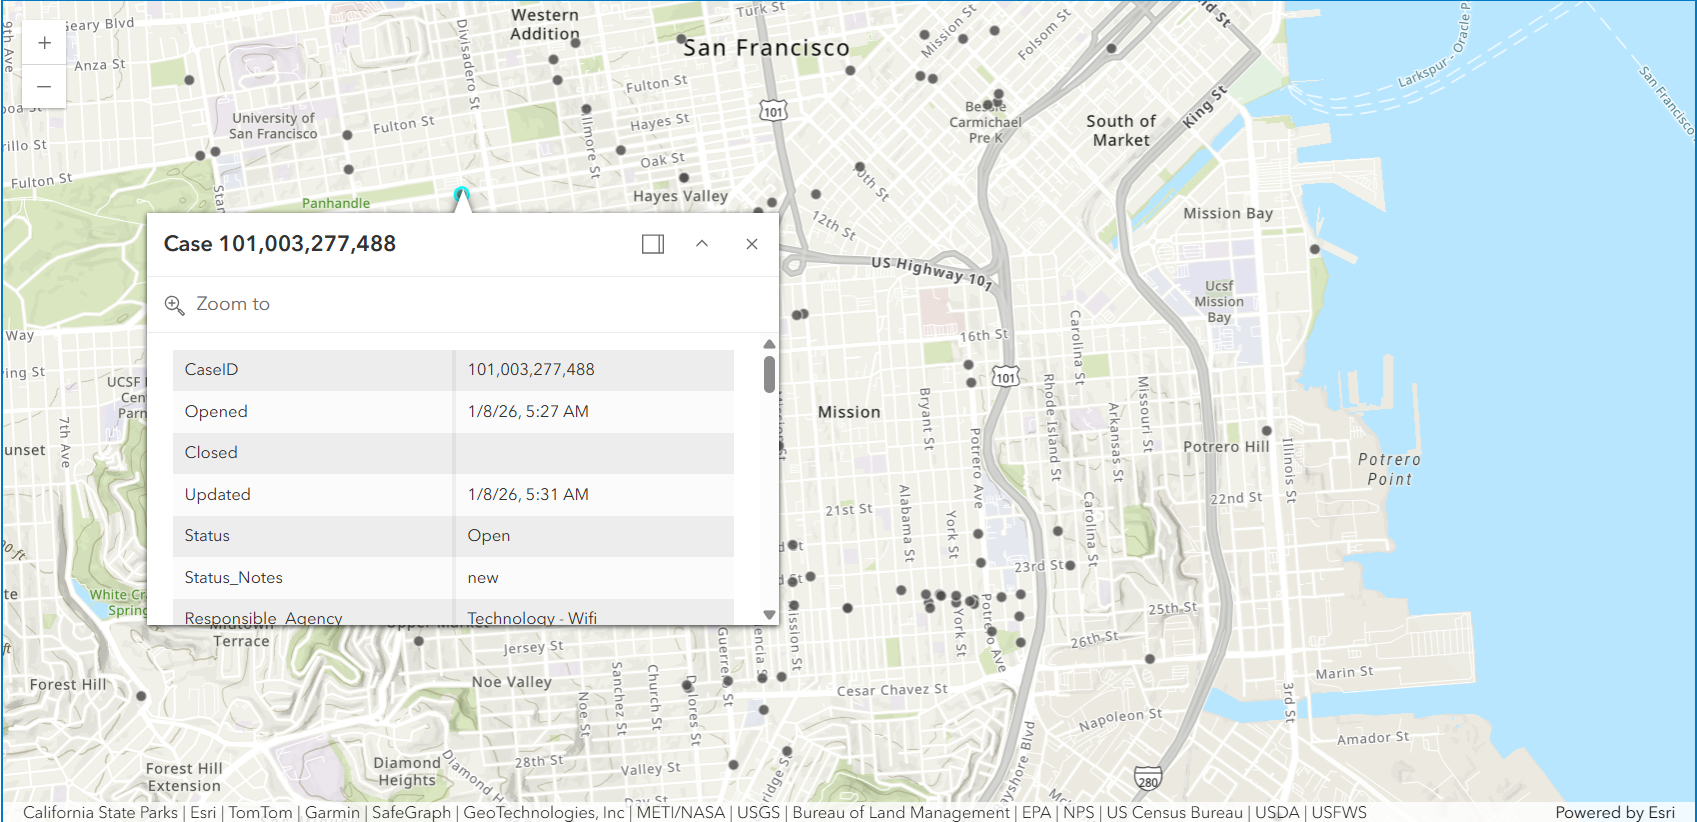

## Image Analysis: Extract Insights from Attachments

Many 311 requests include photos, but these are not directly searchable or structured.

Using `analyze_image`, we:
- Generate captions describing the issue
- Assess severity
- Determine whether the image is usable

These outputs are stored as new fields in the feature layer.

### Prepare Image Prompts

Prompts define how the AI interprets each image.

We enforce:
- Structured JSON output
- Clear constraints (length, content)
- Consistent formatting for storage

In [ ]:
image_prompt_data = [
    {
      "key": "image_caption",
      "context": "Generate a concise caption for an Open311 photo. Return ONLY JSON: {'image_caption':string}. Constraints:- 80–140 characters. - Describe visible issue + location cue if visible (e.g., 'curb', 'sidewalk', 'street', 'park'). - No personal descriptions. No speculation."
    },
    {
      "key": "image_tags",
      "context": "Use ONLY tags from this list when possible: ['pothole','road_crack','broken_sidewalk','uneven_sidewalk','graffiti','illegal_dumping','overflowing_trash','litter','standing_water','flooding','fallen_tree','downed_branch', 'blocked_lane','blocked_sidewalk','damaged_sign','damaged_signal','streetlight_out', 'construction_debris','broken_glass','biohazard','smoke','fire','vehicle_damage', 'park_issue', 'photo_clear','photo_blurry','photo_dark','photo_glare','photo_too_far','photo_irrelevant']. If nothing matches, include 'unknown_issue'."
    },
    {
      "key": "image_severity",
      "context": "Rate severity for Open311 photos in San Francisco. Return ONLY JSON: {'image_severity':1|2|3|4|5, 'rationale':string}. Rubric: 1) minor aesthetic issue, no safety impact visible. 2) small issue, low risk/inconvenience. 3) moderate impact, localized risk or obstruction 4) major impact, clear hazard or blocks access/traffic. 5) critical/acute hazard (fire/smoke, downed wires, collapse, major flooding, severe obstruction). Rules: Base rating strictly on what is visible in the photo. If the photo is not usable, still provide best-effort severity as 1 and say why."
    },
    {
      "key": "image_usable",
      "context": "Decide whether this Open311 photo is usable as evidence of the issue. Return ONLY JSON: {'image_usable':boolean, image_usable_reason':string, 'photo_condition':[string,...]}. Rules: image_usable=false if the issue is not visible OR photo is too blurry/dark/overexposed/too far/blocked/irrelevant."
    }
]

In [ ]:
# -----------------------------------------------------------------------------
# Query all feature ObjectIDs to identify records to evaluate
# -----------------------------------------------------------------------------
oid_field = fl.properties.objectIdField
fs = fl.query(where="1=1", out_fields=oid_field, return_geometry=False)
object_ids = [f.attributes[oid_field] for f in fs.features]

# -----------------------------------------------------------------------------
# Prepare to collect structured image analysis results for updates
# -----------------------------------------------------------------------------
updates = []
skipped_no_attachment = 0

# -----------------------------------------------------------------------------
# Loop through each feature
# -----------------------------------------------------------------------------
for oid in object_ids:
    url = _first_attachment_url(fl, oid, gis)
    if not url:
        skipped_no_attachment += 1
        continue

    # Analyze the image using the predefined prompt
    results = analyze_image(url, image_prompt_data).results
    
    # Convert output data into layer-ready attributes
    attrs = normalize_image_results(results)
    attrs[oid_field] = oid
    updates.append({"attributes": attrs})

# -----------------------------------------------------------------------------
# Write image analysis results back to the feature layer under new fields
# -----------------------------------------------------------------------------
for batch in _chunk(updates, size=200):
    fl.edit_features(updates=batch)

## Text Analysis: Summarize Requests

Request descriptions often contain inconsistent or verbose information.

Using `analyze_text`, we:
- Generate concise summaries
- Remove unnecessary details
- Standardize how requests are interpreted

This creates a consistent representation of each case.

In [ ]:
text_prompt_data = [
    {
        "key": "ai_summary",
        "context": (
            "Summarize this Open311 request context into 1–2 sentences (max 500 characters). "
            "Be factual; do not add details not in the text. Redact personal contact info. "
            "Return ONLY JSON: {'ai_summary': string}"
        ),
    },
    {
        "key": "ai_priority",
        "context": (
            "You are scoring urgency for a San Francisco Open311 service request. "
            "Return ONLY JSON: {'ai_priority':1|2|3|4|5, 'ai_flags':[string,...], 'rationale':string}. "
            "Use these flags only: ['public_safety','injury_reported','fire_or_smoke','downed_wire','gas_smell','flooding',"
            " 'blocked_lane','blocked_sidewalk','accessibility_impact','traffic_signal_out','biohazard','hazmat_suspected',"
            " 'crime_sensitive','child_safety','school_nearby','repeat_issue','needs_more_info','possible_duplicate','low_confidence']. "
            "Priority rubric: 1 cosmetic/minor, 2 low urgency maintenance, 3 moderate impact, 4 significant hazard/disruption, 5 critical imminent danger. "
            "Rules: use text only; no extra inference. If vague/ambiguous, include 'low_confidence' and lower priority."
        ),
    },
]

In [ ]:
# -----------------------------------------------------------------------------
# Select the fields needed to build a complete text “case context” per request
# -----------------------------------------------------------------------------
fields_for_text = [
    "Responsible_Agency",
    "Category",
    "Request_Type",
    "Address",
    "Analysis_Neighborhood",
    "image_caption",
    "image_severity_rationale",
    "image_usable_reason",
]

fs = fl.query(
    where="1=1",
    out_fields=",".join([oid_field] + fields_for_text),
    return_geometry=False
)

# Prepare to collect structured text analysis results for updates
updates = []

# -----------------------------------------------------------------------------
# Loop through each feature
# -----------------------------------------------------------------------------
for f in fs.features:
    a = f.attributes

    txt = (
        f"Responsible agency: {a.get('Responsible_Agency')}, "
        f"Category: {a.get('Category')}, "
        f"Request type: {a.get('Request_Type')}, "
        f"Address: {a.get('Address')}, "
        f"Neighborhood: {a.get('Analysis_Neighborhood')}. "
        f"Photo context: {a.get('image_caption')}. "
        f"{a.get('image_severity_rationale')}. "
        f"{a.get('image_usable_reason')}."
    )

    # Analyze the request context to produce a summary + priority score
    results = analyze_text(txt, text_prompt_data).results
    attrs = normalize_text_results(results)
    attrs[oid_field] = a.get(oid_field)
    updates.append({"attributes": attrs})

# -----------------------------------------------------------------------------
# Write text analysis results back to the feature layer as fields
# -----------------------------------------------------------------------------
for batch in _chunk(updates, size=200):
    fl.edit_features(updates=batch)


## Translate Summaries

To support multilingual workflows, summaries are translated into:
- Spanish
- Simplified Chinese

This enables broader accessibility for global teams and communities.

In [ ]:
# -----------------------------------------------------------------------------
# Query features that contain the AI-generated summary
# -----------------------------------------------------------------------------
fs = fl.query(
    where="1=1",
    out_fields=",".join([oid_field, "ai_summary"]),
    return_geometry=False
)

# Prepare to collect translated summaries for batch updates
updates = []

# -----------------------------------------------------------------------------
# Loop through each feature
# -----------------------------------------------------------------------------
for f in fs.features:
    a = f.attributes
    summary = a.get("ai_summary")
    if not summary:
        continue

    # Translate summary to Spanish and Simplified Chinese
    res_list = translate(
        text=summary,
        to_language=["es", "zh-CN"],
        from_language="en"
    ).results

    attrs = {
        oid_field: a.get(oid_field),
        "ai_summary_es": None,
        "ai_summary_zh": None,
    }
    # Extract translated text from structured results
    for res in res_list:
        for t in (res.translations or []):
            if t.get("to") == "es":
                attrs["ai_summary_es"] = _safe_field_text(t.get("text"))
            elif (t.get("to") or "").lower() in ("zh-hans", "zh-cn"):
                attrs["ai_summary_zh"] = _safe_field_text(t.get("text"))

    updates.append({"attributes": attrs})

# -----------------------------------------------------------------------------
# Write translated summaries back to the feature layer as fields
# -----------------------------------------------------------------------------
for batch in _chunk(updates, size=200):
    fl.edit_features(updates=batch)


### Inspect Additional Data

We can review the updated feature layer as a DataFrame to confirm:
- New AI fields are populated
- Outputs are structured correctly

In [ ]:
df = pd.DataFrame.spatial.from_layer(fl)
df.head(1)

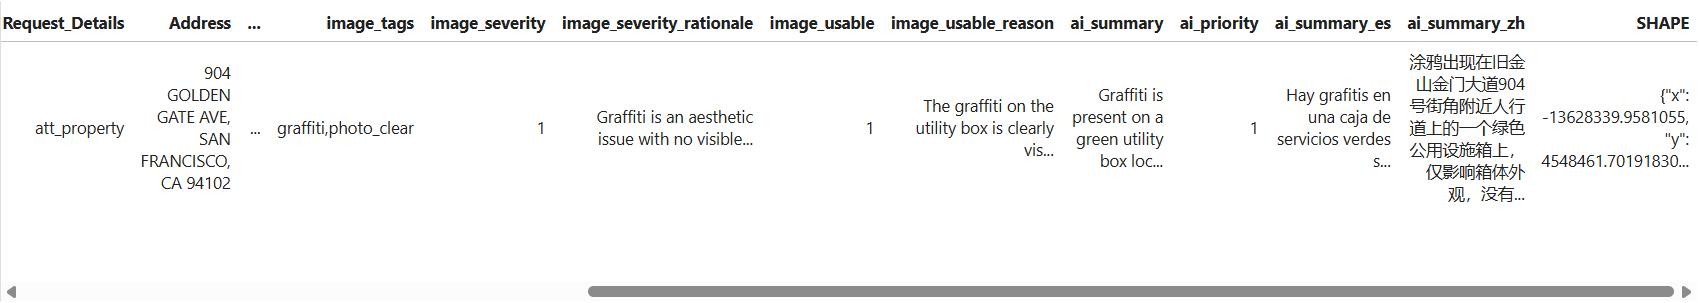

## Visualize Informational Results

With AI-generated fields in place, we can now visualize the data more effectively.

Requests are symbolized by **AI-derived priority**, allowing:
- Faster identification of critical issues
- Better allocation of resources
- Immediate visual insight into service demand

### Configure Renderer and Popup

We define:
- A **class breaks renderer** based on priority
- A **rich popup** displaying:
  - AI summaries (multi-language)
  - Image-based severity insights
  - Responsible agency

This transforms each feature into an actionable unit of information.

In [ ]:
outline = {"color": [60, 60, 60, 180], "width": 0.8}

sym_p1 = SimpleMarkerSymbol(
    style="esriSMSCircle",
    color=[102, 187, 106, 210],
    size=7,
    outline=outline
)

sym_p2 = SimpleMarkerSymbol(
    style="esriSMSCircle",
    color=[255, 202, 40, 220],
    size=8,
    outline=outline
)

sym_p3 = SimpleMarkerSymbol(
    style="esriSMSCircle",
    color=[255, 112, 67, 230],
    size=9.5,
    outline=outline
)

sym_p4 = SimpleMarkerSymbol(
    style="esriSMSCircle",
    color=[198, 40, 40, 240],
    size=11,
    outline=outline
)

priority_renderer = ClassBreaksRenderer(
    field="ai_priority",
    classificationMethod="esriClassifyManual",
    defaultLabel="No priority",
    defaultSymbol=SimpleMarkerSymbol(
        style="esriSMSCircle",
        color=[158, 158, 158, 140],
        size=6,
        outline={"color":[80,80,80,120], "width":0.8}
    ),
    classBreakInfos=[
        ClassBreakInfo(classMaxValue=1, label="1 (Minor)", symbol=sym_p1),
        ClassBreakInfo(classMaxValue=2, label="2 (Low)", symbol=sym_p2),
        ClassBreakInfo(classMaxValue=3, label="3 (Moderate)", symbol=sym_p3),
        ClassBreakInfo(classMaxValue=5, label="4–5 (High/Critical)", symbol=sym_p4),
    ],
)

popup = PopupInfo(
    title="Case Priority: {expression/priority_label}",
    description="""
    <div style="font-size:16px; line-height:1.6;">

      <b>Responsible Agency:</b>
      <span style="font-size:18px; color:#2c3e50;">
      {Responsible_Agency}
      </span>

      <hr>

      <b>AI Summary</b><br>
      <b>English:</b> {ai_summary}<br><br>
      <b>Spanish:</b> {ai_summary_es}<br><br>
      <b>Simplified Chinese:</b> {ai_summary_zh}<br><br>

      <hr>

      <b>Image Severity Assessment</b><br>
      <b>Severity Level:</b> {image_severity}<br>
      <i>{image_severity_rationale}</i>

    </div>
    """,
    show_attachments=True,
    expression_infos=[
        {
            "name": "priority_label",
            "expression": """
            var p = $feature.ai_priority;
            if (p <= 2) { return "Low"; }
            else if (p == 3) { return "Medium"; }
            else if (p >= 4) { return "High"; }
            else { return "Unknown"; }
            """,
        }
    ],
)

### Final Result

The map now reflects informative, structured service requests.

What began as unstructured public submissions is now:
- Interpreted using AI
- Standardized across records
- Visualized for decision-making

This demonstrates how AI Utility Services can be embedded directly into GIS workflows—enabling scalable, automated data enhancement within a single Python environment.

In [ ]:
m = Map("Mission, San Francisco")
m.content.add(fl, drawing_info={"renderer": priority_renderer}, popup_info=popup)
m

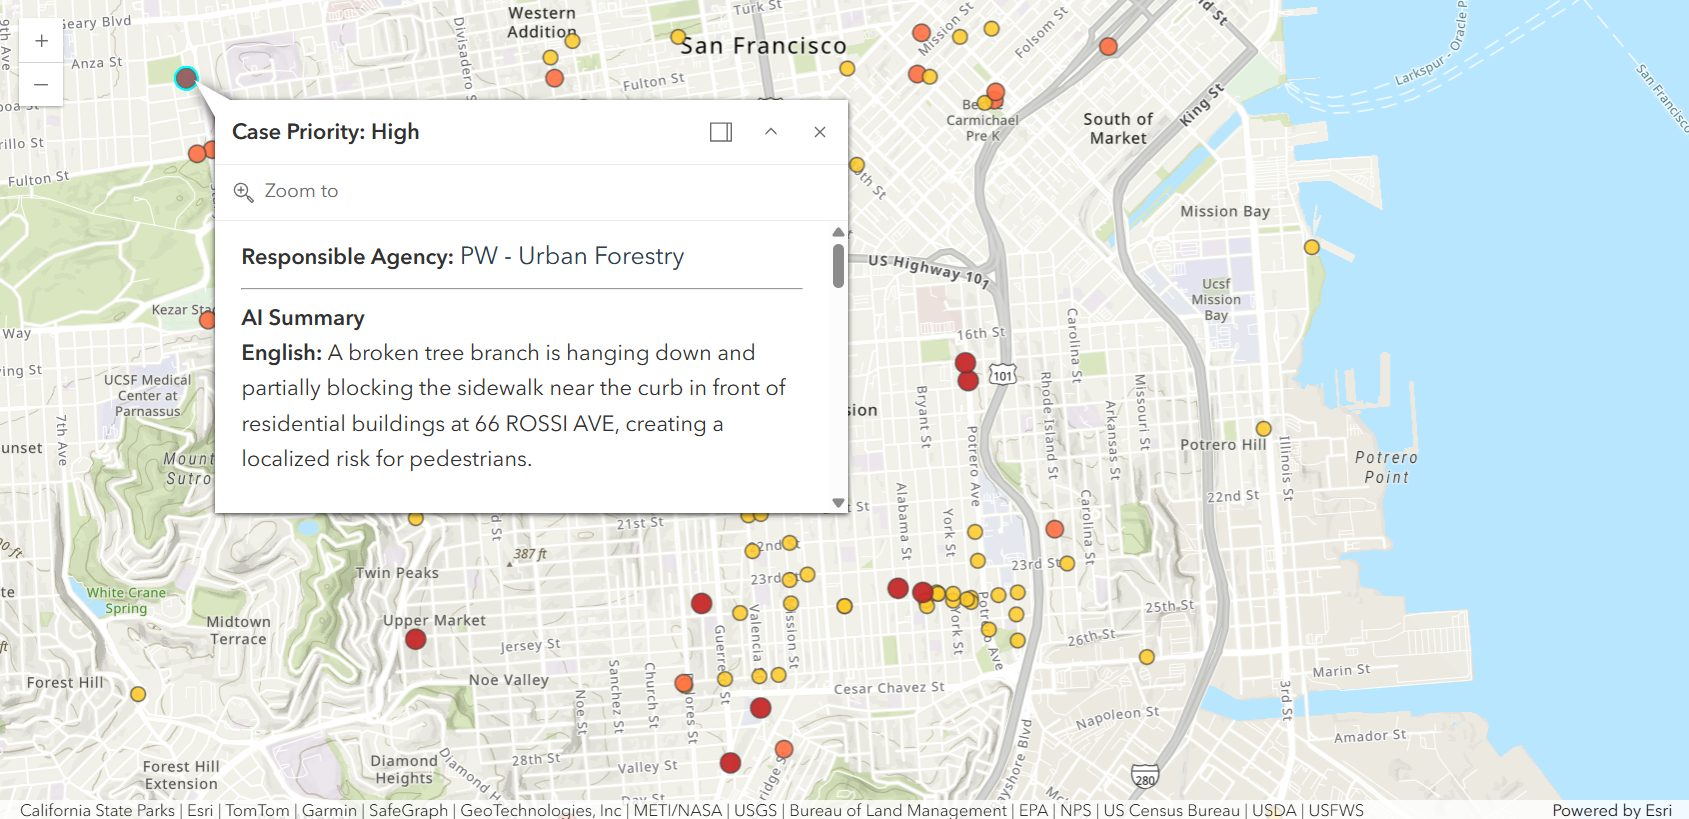

## Summary

In this sample, you learned how to:

- Apply AI to both images and text
- Structure AI outputs for GIS workflows
- Enhance feature layers with new attributes
- Visualize results using renderers and popups

This pattern can be extended to:
- Emergency response workflows
- Asset inspections
- Citizen engagement platforms